# Magnetic Field Effects (MFE) on Radical-Pair Reaction Yields

This notebook simulates how the **product yield of a singlet-born radical pair** changes
when an external magnetic field is applied. We are interested in the *intensity*
dependence of the effect (a **MARY** curve – *Magnetically Altered Reaction Yield*).

### The physics in a nutshell
A radical pair is created in a pure **singlet** state. The two electron spins then
interconvert coherently between **singlet (S)** and **triplet (T)** states, driven by:

- **Hyperfine interactions** (electron–nucleus coupling, internal magnetic fields)
- **Zeeman interaction** (electron–external field coupling)

Two reactions compete to remove the radical pair:

- **Singlet recombination** with rate constant $k_S$ (only the singlet can do this)
- **Forward / escape reaction** with rate constant $k_C$ (spin-independent)

Spin coherence is also lost through **relaxation** with rate $k_\text{relax}$.

### What we solve
We work in **Liouville space** and compute the *time-integrated* density operator

$$
\bar{\rho} \;=\; \int_0^{\infty}\rho(t)\,\mathrm{d}t \;=\; \hat{L}^{-1}\,\rho(0),
$$

where the Liouvillian super-operator is

$$
\hat{L} \;=\; \underbrace{i\,(\,\mathbb{I}\otimes H - H^{\mathsf{T}}\otimes \mathbb{I}\,)}_{\text{coherent evolution}}
\;+\; \underbrace{\hat{W}}_{\text{relaxation}}
\;+\; \underbrace{\tfrac{k_S}{2}\,(\mathbb{I}\otimes P_S + P_S^{\mathsf{T}}\otimes \mathbb{I})}_{\text{singlet recombination}}
\;+\; \underbrace{k_C\,\mathbb{I}}_{\text{forward reaction}} .
$$

The Hamiltonian (in rad s⁻¹) contains the hyperfine and Zeeman terms

$$
H \;=\; \sum_{j} a_{1j}\,\mathbf{S}_1\!\cdot\!\mathbf{I}_{1j}
      \;+\; \sum_{j} a_{2j}\,\mathbf{S}_2\!\cdot\!\mathbf{I}_{2j}
      \;+\; \frac{\mu_B}{\hbar}\,B\,(g_1 S_{1z} + g_2 S_{2z}),
$$

and the singlet projector is

$$
P_S \;=\; \tfrac{1}{4}\,\mathbb{I} \;-\; \mathbf{S}_1\!\cdot\!\mathbf{S}_2 .
$$

The product yields are then

$$
\Phi_C = k_C\,\mathrm{Tr}(\bar{\rho}), \qquad
\Phi_S = k_S\,\mathrm{Tr}(P_S\,\bar{\rho}),
$$

and the magnetic field effect we report is

$$
\Delta\Phi_C \;=\; \Phi_C(B) - \Phi_C(0).
$$

### How to use this notebook
> **You only need to edit Cell 2.** Enter your radical-pair name, $g$-values,
> hyperfine couplings, and the scan settings there. Then just run every cell
> from top to bottom. Outputs (CSV + PNG) are saved automatically and the runs
> are *crash-resistant* (already-computed points are skipped on re-run).

In [1]:
# Importing the numerical, sparse-algebra, data-handling, and plotting libraries


import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import csv, os, time, warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


print("All files imported successfully!!!")

All files imported successfully!!!


In [2]:
#  USER INPUTS  —  edit ONLY this cell, then run the notebook


# Naming the radical pair (this label is reused in every output filename)
radicalPairName = "TrpFAD"


# Isotropic electron g-values
g1 = 2.00277     # Donor radical    (electron 1)
g2 = 2.00367     # Acceptor radical (electron 2)


# Hyperfine couplings, entered as (I, a_iso in MHz)
# Using I = 0.5 for H-1 / P-31, and I = 1 for N-14.
# Commenting out a line removes that nucleus from the simulation.

nucleiRadical1 = [
    (0.5, 37.72790),
    (0.5, -16.00730),
]

nucleiRadical2 = [
    (1, 20.57138),
    (0.5, 17.80635),
    (0.5, 17.29742)
]


# Spin-relaxation rate (s^-1)
k_relax = 1.0e6


# Grid-search settings (finding the rate constants that maximise the MFE)
B_grid    = 50.0e-6     # Fixed field used during the grid search (Tesla)
grid_size = 15          # Number of points per axis (total points = grid_size^2)
log_kS_min, log_kS_max = 5, 7   # Scanning kS over 10^5 ... 10^8 s^-1
log_kC_min, log_kC_max = 5, 7   # Scanning kC over 10^5 ... 10^8 s^-1


# MARY-curve settings (final field sweep at the optimal rates)
B_max_mT   = 30e-3      # Field end-point in mT (sweeping from 0 up to this value)
n_low = 200         # Number of data points in low-field region  (0-1 mT)
n_mid = 100         # Number of data points in mid-field region  (1-10 mT)
n_high = 50         # Number of data points in high-field region (10 mT-B_max)

# Building the output file names from the radical-pair label
csv_grid  = f"{radicalPairName}_MFE_Grid.csv"
png_grid  = f"{radicalPairName}_MFE_Grid.png"
csv_mary  = f"{radicalPairName}_MARY.csv"
png_mary  = f"{radicalPairName}_MARY.png"

print(f"Radical pair      : {radicalPairName}")


# Computing the Hilbert-space dimensions of the full spin system
# (2 electrons, each spin-1/2, plus every coupled nucleus with dimension 2I+1)
N = 2*2            # Starting from the two electrons
dims = [2, 2] + [int(2*I+1) for I,_ in nucleiRadical1] \
              + [int(2*I+1) for I,_ in nucleiRadical2]
N = int(np.prod(dims))   # Total Hilbert-space dimension
print(f"Hilbert Space        : {N}x{N}")
print(f"Liouville Space      : {N*N}x{N*N}")

Radical pair      : TrpFAD
Hilbert Space        : 192x192
Liouville Space      : 36864x36864


## Building the single-spin operators

Defining a helper that returns the Cartesian spin operators $S_x, S_y, S_z$ for a
spin of quantum number $I$ (dimension $2I+1$). These are constructed from the
raising/lowering operators

$$
S_\pm \,|I,m\rangle = \sqrt{I(I+1) - m(m\pm 1)}\;|I,m\pm 1\rangle,
\qquad
S_x = \tfrac{1}{2}(S_+ + S_-),\;\; S_y = \tfrac{1}{2i}(S_+ - S_-).
$$

In [3]:
MU_B = 9.27410e-24      # Bohr magneton (J/T)
HBAR = 1.05457e-34      # Reduced Planck constant (J s)

# Returning the Sx, Sy, Sz operators for a spin of quantum number I (dimension 2I+1)
def spinOperators(I):

    dim = int(2*I + 1)
    ms = np.arange(I, -I-1, -1)          # Listing the magnetic quantum numbers
    Sz = np.diag(ms).astype(complex)     # Building Sz as a diagonal matrix

    # Constructing the raising operator S+
    Sp = np.zeros((dim, dim), dtype=complex)
    for i in range(dim-1):
      m = ms[i+1]
      Sp[i, i+1] = np.sqrt(I*(I+1) - m*(m+1))
    Sm = Sp.T.copy()                     # Obtaining S- as the transpose of S+

    # Returning Sx, Sy, Sz built from S+ and S-
    return 0.5*(Sp+Sm), -0.5j*(Sp-Sm), Sz

## Pre-computing everything that does *not* depend on the field

Two helpers are defined here:

- **`fullSpace`** — embeds a single-particle operator into the full tensor-product
  Hilbert space by Kronecker-padding it with identities on all other particles.

- **`preCompute`** — builds, once and for all, every field-independent super-operator
  needed by the Liouvillian:
  the hyperfine Hamiltonian commutator, the (per-Tesla) Zeeman commutators, the
  relaxation super-operator $\hat{W}$, the Haberkorn singlet anticommutator,
  the identity, and the vectorised initial state $\rho(0)=P_S/\mathrm{Tr}(P_S)$.

Separating the field-independent build from the per-field solve keeps the grid
search and MARY sweep fast, because the heavy matrices are assembled only once.

In [4]:
def fullSpace(op, pos, dims):
    # op   = the single-particle operator
    # pos  = which particle it acts on
    # dims = list of dimensions for every particle in the system
    parts = [sparse.csr_matrix(op) if i == pos
             else sparse.eye(d, format='csr')
             for i, d in enumerate(dims)]
    out = parts[0]
    for p in parts[1:]:
        out = sparse.kron(out, p, format='csr')   # Tensoring the pieces together
    return out


def preCompute(n1, n2, g1, g2, dims, N, k_relax):
    """
    Returns a dictionary with:
        lH_hf   – Liouville Hamiltonian commutator (HF only)
        lH_Z1   – Liouville Zeeman for 1 T on electron-1
        lH_Z2   – Liouville Zeeman for 1 T on electron-2
        lW      – relaxation superoperator
        pSS     – Haberkorn singlet anticommutator superoperator
        IN2     – identity in Liouville space
        rho0    – vec(ρ₀)   (singlet initial state)
        pS_full – singlet projector  P_S  (Hilbert space)
        N       – Hilbert space dimension
    """

    IN  = sparse.eye(N, format='csr')   # Defining the Hilbert-space identity

    # Building the electron spin operators in the full space
    e1 = [fullSpace(op, 0, dims) for op in spinOperators(0.5)]
    e2 = [fullSpace(op, 1, dims) for op in spinOperators(0.5)]

    # Assembling the hyperfine Hamiltonian (rad/s):  H_hf = Σ a_j S·I_j
    H_hf = sparse.csr_matrix((N, N), dtype=complex)
    idx = 2         # Skipping slots 0 and 1, which are the two electrons
    for (sI, aMHz) in n1:
        a = aMHz * 2*np.pi*1e6      # Converting MHz to rad/s
        nuc = [fullSpace(op, idx, dims) for op in spinOperators(sI)]
        for p in range(3):
            H_hf += a * e1[p] @ nuc[p]     # Coupling nucleus to electron 1
        idx += 1
    for (sI, aMHz) in n2:
        a = aMHz * 2*np.pi*1e6
        nuc = [fullSpace(op, idx, dims) for op in spinOperators(sI)]
        for p in range(3):
            H_hf += a * e2[p] @ nuc[p]     # Coupling nucleus to electron 2
        idx += 1

    # Building the Zeeman operators for B = 1 T (scaling by the real B happens later)
    H_Z1 = (g1 * MU_B / HBAR) * e1[2]
    H_Z2 = (g2 * MU_B / HBAR) * e2[2]

    # Converting a Hamiltonian into its commutator super-operator:  +i(I⊗H − Hᵀ⊗I)
    def commSup(H):
        return 1j * (sparse.kron(IN, H, 'csr')
                    - sparse.kron(H.T, IN, 'csr'))

    lH_hf = commSup(H_hf)
    lH_Z1 = commSup(H_Z1)
    lH_Z2 = commSup(H_Z2)

    # Constructing the two-electron singlet projector  P_S = (1/4)I − S₁·S₂
    Sx1, Sy1, Sz1 = spinOperators(0.5)
    Sx2, Sy2, Sz2 = spinOperators(0.5)
    I4 = sparse.eye(4, format='csr')
    s1e = [sparse.kron(sparse.csr_matrix(o), sparse.eye(2), 'csr')
           for o in (Sx1, Sy1, Sz1)]
    s2e = [sparse.kron(sparse.eye(2), sparse.csr_matrix(o), 'csr')
           for o in (Sx2, Sy2, Sz2)]
    PS_e = 0.25 * I4
    for p in range(3):
        PS_e = PS_e - s1e[p] @ s2e[p]

    # Extending the singlet projector over the nuclear sub-space
    nuc_dim  = N // 4
    pS_full  = sparse.kron(sparse.csr_matrix(PS_e),
                           sparse.eye(nuc_dim), 'csr')

    # Building the Haberkorn singlet anticommutator super-operator  {P_S, ρ}
    pSS = (sparse.kron(IN, pS_full, 'csr')
         + sparse.kron(pS_full.T, IN, 'csr'))

    # Preparing the initial (singlet) state  ρ₀ = P_S / Tr(P_S)  and vectorising it
    trPS = np.real(pS_full.diagonal().sum())
    rho0_mat = pS_full / trPS
    rho0_vec = rho0_mat.toarray().flatten(order='C')

    # Building the random-fields relaxation super-operator  k·[S,[S,ρ]]
    lW = sparse.csr_matrix((N*N, N*N), dtype=complex)
    if k_relax > 0:
        for sOp in list(e1) + list(e2):
            s2 = sOp @ sOp
            lW += k_relax * (
                sparse.kron(IN, s2, 'csr')
              + sparse.kron(s2.T, IN, 'csr')
              - 2.0 * sparse.kron(sOp.conj(), sOp, 'csr'))

    IN2 = sparse.eye(N*N, format='csr')   # Defining the Liouville-space identity

    # Returning every field-independent ingredient in a single dictionary
    return dict(lH_hf=lH_hf, lH_Z1=lH_Z1, lH_Z2=lH_Z2,
                lW=lW, pSS=pSS, IN2=IN2,
                rho0=rho0_vec, pS_full=pS_full, N=N)

## Computing the yields at a given field

Assembling the full Liouvillian for a specific field $B$ and rate constants
$k_S, k_C$, solving the linear system $\hat{L}\,\bar{\rho} = \rho(0)$ for the
time-integrated density operator, and extracting the two product yields:

$$
\Phi_C = k_C\,\mathrm{Tr}(\bar{\rho}), \qquad
\Phi_S = k_S\,\mathrm{Tr}(P_S\,\bar{\rho}).
$$

Finally, running `preCompute` once to cache all the field-independent matrices.

In [5]:
def yieldAtB(pre, B_T, kS, kC):

    N = pre['N']

    # Assembling the field-dependent Liouvillian L = i[H,·] + W + (kS/2){P_S,·} + kC·I
    lH = pre['lH_hf'] + B_T * (pre['lH_Z1'] + pre['lH_Z2'])
    L  = (lH
        + pre['lW']
        + (kS / 2.0) * pre['pSS']
        + kC * pre['IN2'])

    # Solving L · vec(ρ̄) = vec(ρ₀) for the time-integrated density operator
    x = spsolve(L, pre['rho0'])
    rho_int = x.reshape((N, N), order='C')

    # Extracting the forward-product and singlet-recombination yields
    phi_C = kC * np.real(np.trace(rho_int))
    phi_S = kS * np.real(np.trace(pre['pS_full'].toarray() @ rho_int))
    return phi_C, phi_S

pre = preCompute(nucleiRadical1, nucleiRadical2, g1, g2, dims, N, k_relax)

## Scanning the rate-constant plane ($k_S$ vs $k_C$)

Sweeping $k_S$ and $k_C$ over the logarithmic ranges set in Cell 2 and, at each
point, computing the magnetic field effect

$$
\text{MFE} = \Phi_C(B_\text{grid}) - \Phi_C(0).
$$

The results stream to `csv_grid` row-by-row. The run is **crash-resistant**: if the
CSV already exists, previously computed `(kS, kC)` points are loaded and skipped,
so you can safely re-run after an interruption.

In [6]:
# Generating the logarithmically spaced rate-constant grids
ks_vals = np.logspace(log_kS_min, log_kS_max, grid_size)
kc_vals = np.logspace(log_kC_min, log_kC_max, grid_size)


# Loading any already-computed rows so the scan can resume after a crash
done = set()
if os.path.isfile(csv_grid):
    with open(csv_grid) as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if len(row) >= 2:
                done.add((row[0], row[1]))
    print(f"Resuming: {len(done)} points already in {csv_grid}")


# Opening the CSV for appending and writing a header if the file is new/empty
write_header = not os.path.isfile(csv_grid) or len(done) == 0
fout = open(csv_grid, 'a', newline='')
writer = csv.writer(fout)
if write_header:
    writer.writerow(["kS_s-1", "kC_s-1",
                     "PhiC_0T", f"PhiC_{B_grid*1e6:.0f}uT",
                     "PhiS_0T", f"PhiS_{B_grid*1e6:.0f}uT",
                     "MFE"])

total = grid_size**2
count = len(done)
t_start = time.time()


# Looping over every (kS, kC) pair on the grid
for kS in ks_vals:
    for kC in kc_vals:
        key = (f"{kS:.6e}", f"{kC:.6e}")
        if key in done:
            continue                       # Skipping points already computed

        # Computing the yields with the field off and on
        y0_C, y0_S = yieldAtB(pre, 0.0,    kS, kC)
        yB_C, yB_S = yieldAtB(pre, B_grid,  kS, kC)
        mfe = yB_C - y0_C                   # Defining the magnetic field effect

        # Writing this point to disk immediately (crash-safe)
        writer.writerow([f"{kS:.6e}", f"{kC:.6e}",
                         f"{y0_C:.8f}", f"{yB_C:.8f}",
                         f"{y0_S:.8f}", f"{yB_S:.8f}",
                         f"{mfe:.8f}"])
        fout.flush()

        # Reporting progress periodically
        count += 1
        if count % 25 == 0 or count == total:
            el = time.time() - t_start
            print(f"  [{count}/{total}]  {el:.1f} s elapsed")


fout.close()
print(f"Grid complete -> {csv_grid}")

Resuming: 225 points already in TrpFAD_MFE_Grid.csv
Grid complete -> TrpFAD_MFE_Grid.csv


Max |MFE| at  kS = 3.73e+06,  kC = 1.93e+06,  ΔΦCM = 0.004195


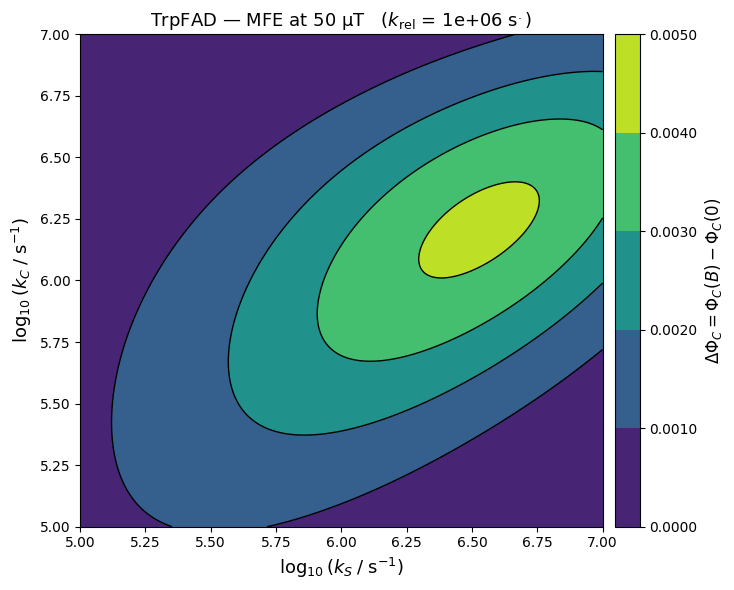

Saved -> TrpFAD_MFE_Grid.png


In [7]:
# Plotting the results in a 2D Contour Plot

from scipy.interpolate import RectBivariateSpline
import matplotlib.ticker as ticker

# Loading the grid data
df = pd.read_csv(csv_grid)
ks_u = np.sort(df["kS_s-1"].unique())
kc_u = np.sort(df["kC_s-1"].unique())

# Reshaping the flat CSV back onto a 2-D MFE grid
mfe_grid = np.full((len(kc_u), len(ks_u)), np.nan)
for _, r in df.iterrows():
    i = np.searchsorted(ks_u, r["kS_s-1"])
    j = np.searchsorted(kc_u, r["kC_s-1"])
    mfe_grid[j, i] = r["MFE"]

# Identifying the rate constants that give the strongest |MFE|
best = df.loc[df["MFE"].abs().idxmax()]
best_kS, best_kC = best["kS_s-1"], best["kC_s-1"]
best_mfe = best["MFE"]
print(f"Max |MFE| at  kS = {best_kS:.2e},  kC = {best_kC:.2e},  ΔΦCM = {best_mfe:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 6))

# Smoothing the grid for display only
spline = RectBivariateSpline(np.log10(kc_u), np.log10(ks_u), mfe_grid)
ks_smooth = np.linspace(np.log10(ks_u).min(), np.log10(ks_u).max(), 300)
kc_smooth = np.linspace(np.log10(kc_u).min(), np.log10(kc_u).max(), 300)
mfe_grid_smooth = spline(kc_smooth, ks_smooth)

# Choosing fully dynamic contour bounds based on the actual data range
step = 0.0010
vmin_data = np.nanmin(mfe_grid)
vmax_data = np.nanmax(mfe_grid)

# Rounding the min down and the max up to the nearest 'step'
vmin_level = np.floor(vmin_data / step) * step
vmax_level = np.ceil(vmax_data / step) * step

# Building the contour levels from the dynamic min to max
levels = np.arange(vmin_level, vmax_level + (step / 2), step)

# Drawing the filled contour map (viridis: blue -> green -> yellow)
im = ax.contourf(ks_smooth, kc_smooth, mfe_grid_smooth,
                 levels=levels,
                 cmap='viridis')

# Overlaying the contour lines (dashed = negative, solid = positive)
lines = ax.contour(ks_smooth, kc_smooth, mfe_grid_smooth,
                   levels=levels,
                   colors='black',
                   linewidths=1)

# Formatting the colourbar
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label(r'$\Delta\Phi_C = \Phi_C(B)-\Phi_C(0)$', fontsize=12)
cb.locator = ticker.MultipleLocator(step)
cb.formatter = ticker.FormatStrFormatter('%.4f')
cb.update_ticks()

ax.set_xlabel(r'$\log_{10}(k_S\;/\;\mathrm{s^{-1}})$', fontsize=13)
ax.set_ylabel(r'$\log_{10}(k_C\;/\;\mathrm{s^{-1}})$', fontsize=13)
ax.set_title(f'{radicalPairName} — MFE at '
             f'{B_grid*1e6:.0f} µT   '
             f'($k_{{\\rm rel}}$ = {k_relax:.0e} s$^.$)',
             fontsize=13)
plt.tight_layout()
plt.savefig(png_grid, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved -> {png_grid}")

## Sweeping the field (building the MARY curve)

Fixing the rate constants at the **optimal** $(k_S, k_C)$ found in Cell 7 and sweeping
the field from 0 up to 30 mT. The field grid is deliberately **non-uniform** — densely
sampled at low field (where the curve changes fastest) and sparser at high field.

Like the grid scan, this sweep streams to `csv_mary` and resumes automatically if
re-run.


In [8]:
# Adopting the optimal rate constants identified by the grid search
opt_kS = best_kS
opt_kC = best_kC
print(f"Optimal rates:  kS = {opt_kS:.3e} s⁻¹,  kC = {opt_kC:.3e} s⁻¹")


# Building a custom (non-uniform) field array: dense at low field, sparse at high field
B_low  = np.linspace(0, 1e-3, n_low, endpoint=False)            # 0 to 1 mT  (fine)
B_mid  = np.linspace(1e-3, 10e-3, n_mid, endpoint=False)        # 1 to 10 mT (medium)
B_high = np.linspace(10e-3, B_max_mT, n_high, endpoint=True)    # 10 to B_max_mT (coarse)
B_array = np.concatenate([B_low, B_mid, B_high])
B_array = np.unique(np.round(B_array, 12))               # Removing any duplicate fields


# Loading any previously computed field points so the sweep can resume
done_B = {}
if os.path.isfile(csv_mary):
    with open(csv_mary) as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if len(row) >= 4:
                done_B[row[0]] = row
    print(f"Resuming: {len(done_B)} B-points already in {csv_mary}")

# Opening the MARY CSV for appending and writing a header if needed
write_hdr = not os.path.isfile(csv_mary) or len(done_B) == 0
fout = open(csv_mary, 'a', newline='')
writer = csv.writer(fout)
if write_hdr:
    writer.writerow(["B_Tesla", "B_mT", "PhiC", "PhiS"])

total = len(B_array)
count_done = len(done_B)
t0 = time.time()

# Sweeping over every field value at the optimal rate constants
for idx, B in enumerate(B_array):
    key = f"{B:.12e}"
    if key in done_B:
        continue                           # Skipping fields already computed

    # Computing the yields at this field
    phi_C, phi_S = yieldAtB(pre, B, opt_kS, opt_kC)
    writer.writerow([f"{B:.12e}", f"{B*1e3:.8f}",
                     f"{phi_C:.10f}", f"{phi_S:.10f}"])
    fout.flush()
    count_done += 1

    # Reporting progress periodically
    if count_done % 20 == 0 or count_done == total:
        el = time.time() - t0
        print(f"  [{count_done}/{total}]  {el:.1f} s")

fout.close()
print(f"MARY sweep complete -> {csv_mary}")

Optimal rates:  kS = 3.728e+06 s⁻¹,  kC = 1.931e+06 s⁻¹
Resuming: 350 B-points already in TrpFAD_MARY.csv
MARY sweep complete -> TrpFAD_MARY.csv


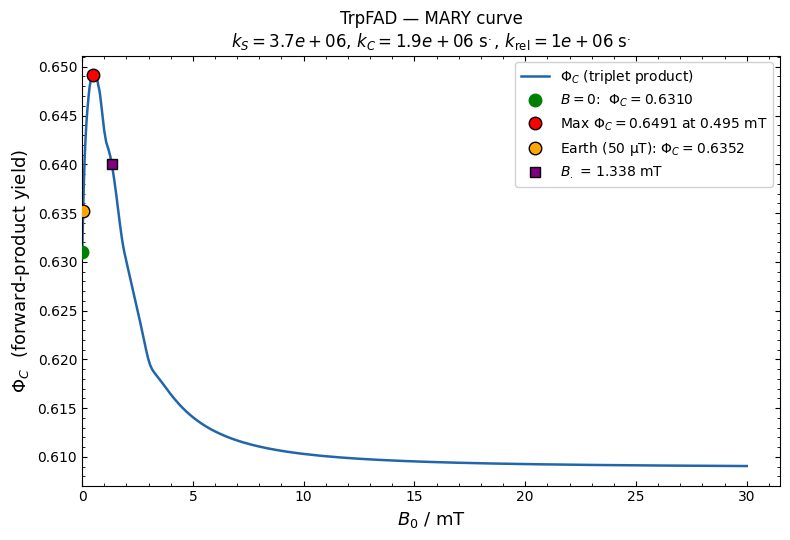

Saved -> TrpFAD_MARY.png


In [9]:
# Loading the MARY sweep and sorting it by field
dm = pd.read_csv(csv_mary)
dm = dm.sort_values("B_Tesla").reset_index(drop=True)

B_mT  = dm["B_mT"].values
phiC  = dm["PhiC"].values
phiS  = dm["PhiS"].values

# Locating the key field points: B=0, the maximum yield, and Earth field (50 µT)
idx0   = 0                              # B = 0 (first row)
idx_max = np.argmax(phiC)               # Maximum yield
idx_earth = np.argmin(np.abs(dm["B_Tesla"].values - 50e-6))

B0   = B_mT[idx0];       y0   = phiC[idx0]
Bmax = B_mT[idx_max];    ymax = phiC[idx_max]
Be   = B_mT[idx_earth];  ye   = phiC[idx_earth]

# Calculating B_1/2 (the field giving half the maximum effect)
mfe_array = phiC - y0
max_mfe = ymax - y0
target_mfe = max_mfe / 2.0
B_half = np.nan

# Interpolating linearly to find the exact half-maximum crossing
for i in range(idx_max, len(mfe_array)):
    if (mfe_array[i-1] <= target_mfe <= mfe_array[i]) or (mfe_array[i-1] >= target_mfe >= mfe_array[i]):
        b1, b2 = B_mT[i-1], B_mT[i]
        m1, m2 = mfe_array[i-1], mfe_array[i]
        B_half = b1 + (b2 - b1) * (target_mfe - m1) / (m2 - m1)
        break

fig, ax = plt.subplots(figsize=(8, 5.5))

# Plotting the forward-product yield versus field
ax.plot(B_mT, phiC, '-', color='#2166ac', lw=1.8,
        label=r'$\Phi_C$ (triplet product)')

# Annotating the diagnostic points
ax.plot(B0,   y0,   'o', color='green',  ms=9, zorder=5,
        label=f'$B=0$:  $\\Phi_C={y0:.4f}$')
ax.plot(Bmax, ymax, 'o', color='red',    ms=9, zorder=5, mec='k',
        label=f'Max $\\Phi_C={ymax:.4f}$ at {Bmax:.3f} mT')
ax.plot(Be,   ye,   'o', color='orange', ms=9,  zorder=5, mec='k',
        label=f'Earth (50 µT): $\\Phi_C={ye:.4f}$')

# Marking the B_1/2 point if it was found
if not np.isnan(B_half):
    y_half = y0 + target_mfe
    ax.plot(B_half, y_half, 's', color='purple', ms=7, zorder=4, mec='k',
            label=f'$B_.$ = {B_half:.3f} mT')

ax.set_xlabel('$B_0$ / mT', fontsize=13)
ax.set_ylabel(r'$\Phi_C$  (forward-product yield)', fontsize=13)
ax.set_title(f'{radicalPairName} — MARY curve\n'
             f'$k_S={opt_kS:.1e}$, $k_C={opt_kC:.1e}$ s$^.$, '
             f'$k_{{\\rm rel}}={k_relax:.0e}$ s$^.$',
             fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig(png_mary, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved -> {png_mary}")

In [10]:
# FINAL SUMMARY REPORT CELL


print("\n" + "="*45)
print(" FINAL MARY CURVE SUMMARY REPORT")
print("="*45)
print(f" Optimal kS        :  {opt_kS:.2e} s⁻¹")
print(f" Optimal kC        :  {opt_kC:.2e} s⁻¹")
print("-" * 45)
print(f" Phi_C at B = 0    :  {y0:.6f}")
print(f" Phi_C at 50 µT    :  {ye:.6f}")
print(f" Maxima Phi_C      :  {ymax:.6f}")
print("-" * 45)
print(f" B_max (Peak)      :  {Bmax:.4f} mT")
print(f" B_1/2 (Half-max)  :  {B_half:.4f} mT")
print("="*45 + "\n")


 FINAL MARY CURVE SUMMARY REPORT
 Optimal kS        :  3.73e+06 s⁻¹
 Optimal kC        :  1.93e+06 s⁻¹
---------------------------------------------
 Phi_C at B = 0    :  0.630979
 Phi_C at 50 µT    :  0.635174
 Maxima Phi_C      :  0.649145
---------------------------------------------
 B_max (Peak)      :  0.4950 mT
 B_1/2 (Half-max)  :  1.3375 mT

